# 1. Problem Understanding 

### Business Problem
- Companies want to predict employee salary based on candidate/job attributes.
### ML Formulation
- Type: Regression Problem
- Target Variable: salary

### Success Metrics
- Primary: R² Score
- Secondary: RMSE (Root Mean Squared Error)

# 2. Data Understanding & EDA

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df= pd.read_csv("job_salary.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,Business Analyst,12,Diploma,19,Healthcare,Startup,Singapore,Yes,7,124782
1,Software Engineer,15,Diploma,3,Technology,Medium,India,No,10,111684
2,Frontend Developer,12,PhD,8,Telecom,Enterprise,Canada,Hybrid,9,132229
3,Business Analyst,3,PhD,16,Manufacturing,Small,Sweden,No,3,100616
4,Data Scientist,3,PhD,17,Telecom,Medium,Sweden,Yes,1,97587
...,...,...,...,...,...,...,...,...,...,...
29995,Data Analyst,20,High School,20,Media,Enterprise,USA,Yes,8,147346
29996,Backend Developer,2,Bachelor,9,Telecom,Medium,Australia,Yes,8,69838
29997,Data Analyst,1,High School,17,Retail,Enterprise,UK,Hybrid,5,72139
29998,Product Manager,13,PhD,14,Manufacturing,Startup,Sweden,Hybrid,3,141129


In [17]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [18]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,Business Analyst,12,Diploma,19,Healthcare,Startup,Singapore,Yes,7,124782
1,Software Engineer,15,Diploma,3,Technology,Medium,India,No,10,111684
2,Frontend Developer,12,PhD,8,Telecom,Enterprise,Canada,Hybrid,9,132229
3,Business Analyst,3,PhD,16,Manufacturing,Small,Sweden,No,3,100616
4,Data Scientist,3,PhD,17,Telecom,Medium,Sweden,Yes,1,97587


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         30000 non-null  object
 1   experience_years  30000 non-null  int64 
 2   education_level   30000 non-null  object
 3   skills_count      30000 non-null  int64 
 4   industry          30000 non-null  object
 5   company_size      30000 non-null  object
 6   location          30000 non-null  object
 7   remote_work       30000 non-null  object
 8   certifications    30000 non-null  int64 
 9   salary            30000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 2.3+ MB


In [20]:
df.describe()

,experience_years,skills_count,certifications,salary
count,30000.00000,30000.000000,30000.000000,30000.000000
mean,10.00440,10.489900,5.009233,108768.557267
std,6.03487,5.764478,3.170765,29163.079587
min,0.00000,1.000000,0.000000,27736.000000
25%,5.00000,6.000000,2.000000,86942.500000
50%,10.00000,10.000000,5.000000,108613.500000
75%,15.00000,15.000000,8.000000,130561.250000
max,20.00000,20.000000,10.000000,197424.000000


C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


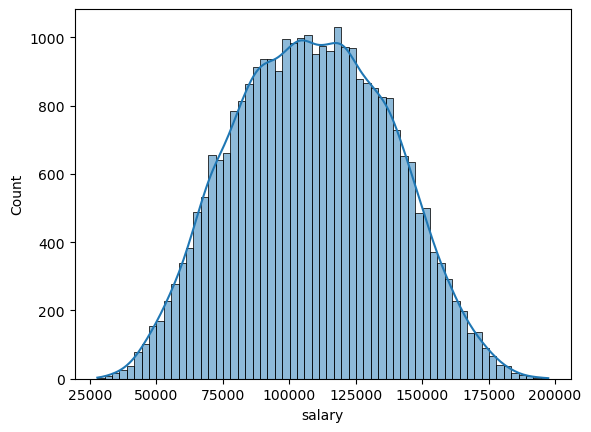

In [21]:
# Salary distribution
sns.histplot(df['salary'], kde=True)
plt.show()

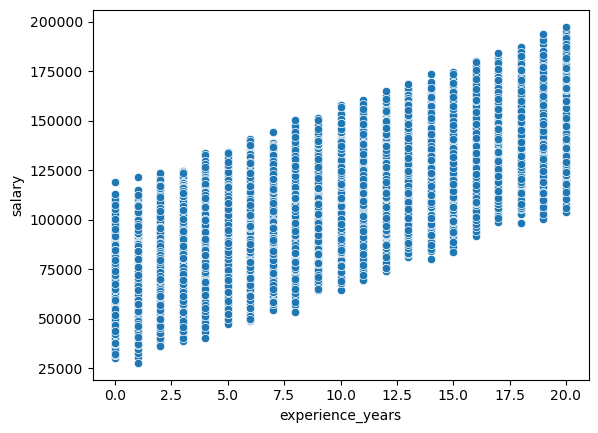

In [22]:

# Experience vs Salary
sns.scatterplot(x='experience_years', y='salary', data=df)
plt.show()

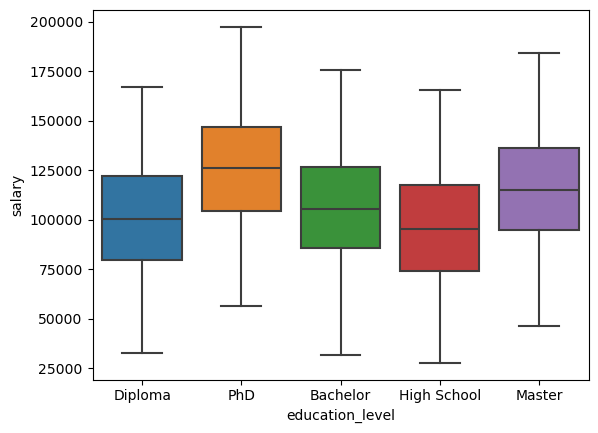

In [23]:

# Education vs Salary
sns.boxplot(x='education_level', y='salary', data=df)
plt.show()

### Insights
- Salary increases with experience
- Higher education → higher salary
- Skills & certifications matter


# 3. Data Preprocessing

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop("salary", axis=1)
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Feature Engineering

- No useless columns → all relevant
- Categorical encoding needed
- Scaling for numeric

In [25]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = ['experience_years', 'skills_count', 'certifications']

cat_cols = ['job_title', 'education_level', 'industry',
            'company_size', 'location', 'remote_work']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 5. Model Selection

### Models tried:
- Linear Regression (baseline)
- Random Forest
- Gradient Boosting (best)

#### Final: Ensemble Model (Voting Regressor)

In [26]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

model = VotingRegressor([
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50))
])

# 6. Model Training & Tuning

In [27]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

# 7. Model Evaluation

In [28]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)

Train R2: 0.9600823696092262
Test R2: 0.9536801876080423
RMSE: 6266.36666939142


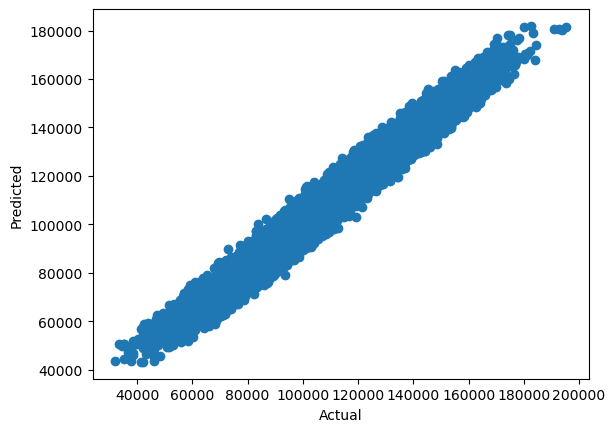

In [29]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# 8. Model Interpretation

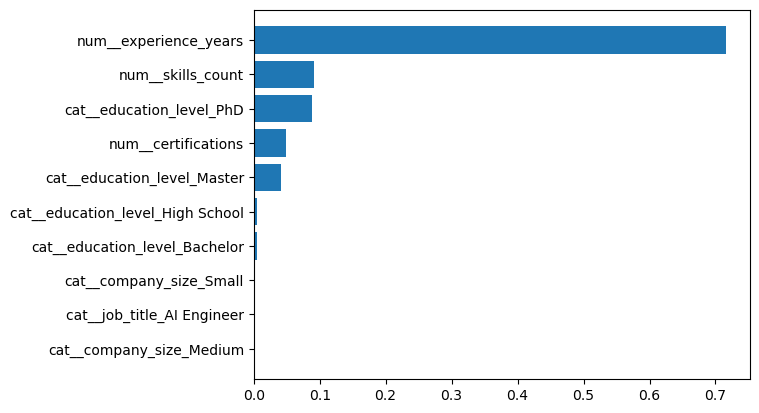

In [30]:
import numpy as np

feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
rf_model = pipeline.named_steps['model'].estimators_[0]

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.show()

### Insights
- Experience_years → strongest factor
- Skills_count → highly impactful
- Education level → major influence

# 9. Deployment Readiness

In [31]:
import joblib

joblib.dump(pipeline, "job_salary.pkl")

['job_salary.pkl']